In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ayushus","key":"763b97d20f825f51f5057eeac16df17f"}'}

In [ ]:
# Set up kaggle API
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

# Unzip dataset
!unzip -q chest-xray-pneumonia.zip


Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
 99% 2.26G/2.29G [00:13<00:00, 217MB/s]
100% 2.29G/2.29G [00:13<00:00, 186MB/s]


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paths
train_dir = "/content/chest_xray/train"
test_dir = "/content/chest_xray/test"
img_size = (224, 224)
batch_size = 32

# Final training data generator with safe augmentations
train_datagen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.15,
    shear_range=0.1,
    rotation_range=15,
    horizontal_flip=True,
    width_shift_range=0.05,
    height_shift_range=0.05,
    brightness_range=[0.9, 1.1],
    validation_split=0.2
)

# 80% training subset
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

# 20% validation subset
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

# Test generator
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)


Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

# Load base model without top, freeze its layers
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # Freeze the base

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)  # Binary classification

# Final model
model = Model(inputs=base_model.input, outputs=output)


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [ ]:
#add callback
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Save the best model
checkpoint = ModelCheckpoint(
    "densenet121_initial.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Stop training if val_accuracy doesn't improve for 3 epochs
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=4,
    restore_best_weights=True,
    verbose=1
)


In [ ]:
#train
# Set number of epochs
epochs = 20

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    epochs=epochs,
    callbacks=[checkpoint, early_stop]
)


Epoch 1/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 659ms/step - accuracy: 0.8741 - loss: 0.3155
Epoch 1: val_accuracy improved from -inf to 0.91113, saving model to densenet121_initial.h5


130/130 ━━━━━━━━━━━━━━━━━━━━ 122s 934ms/step - accuracy: 0.8743 - loss: 0.3153 - val_accuracy: 0.9111 - val_loss: 0.2281
Epoch 2/20
  1/130 ━━━━━━━━━━━━━━━━━━━━ 13s 101ms/step - accuracy: 0.8125 - loss: 0.2876

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.91113 to 0.92090, saving model to densenet121_initial.h5


130/130 ━━━━━━━━━━━━━━━━━━━━ 23s 176ms/step - accuracy: 0.8125 - loss: 0.2876 - val_accuracy: 0.9209 - val_loss: 0.2215
Epoch 3/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 675ms/step - accuracy: 0.9063 - loss: 0.2420
Epoch 3: val_accuracy improved from 0.92090 to 0.93164, saving model to densenet121_initial.h5


130/130 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9063 - loss: 0.2420 - val_accuracy: 0.9316 - val_loss: 0.2071
Epoch 4/20
  1/130 ━━━━━━━━━━━━━━━━━━━━ 12s 93ms/step - accuracy: 0.9688 - loss: 0.1006
Epoch 4: val_accuracy improved from 0.93164 to 0.93457, saving model to densenet121_initial.h5


130/130 ━━━━━━━━━━━━━━━━━━━━ 22s 170ms/step - accuracy: 0.9688 - loss: 0.1006 - val_accuracy: 0.9346 - val_loss: 0.1946
Epoch 5/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 659ms/step - accuracy: 0.9134 - loss: 0.2174
Epoch 5: val_accuracy did not improve from 0.93457
130/130 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.9134 - loss: 0.2174 - val_accuracy: 0.9268 - val_loss: 0.1844
Epoch 6/20
  1/130 ━━━━━━━━━━━━━━━━━━━━ 13s 101ms/step - accuracy: 0.9688 - loss: 0.1180
Epoch 6: val_accuracy did not improve from 0.93457
130/130 ━━━━━━━━━━━━━━━━━━━━ 22s 169ms/step - accuracy: 0.9688 - loss: 0.1180 - val_accuracy: 0.9326 - val_loss: 0.1845
Epoch 7/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 664ms/step - accuracy: 0.9271 - loss: 0.1981
Epoch 7: val_accuracy improved from 0.93457 to 0.94434, saving model to densenet121_initial.h5


130/130 ━━━━━━━━━━━━━━━━━━━━ 110s 843ms/step - accuracy: 0.9271 - loss: 0.1981 - val_accuracy: 0.9443 - val_loss: 0.1634
Epoch 8/20
  1/130 ━━━━━━━━━━━━━━━━━━━━ 13s 105ms/step - accuracy: 0.9062 - loss: 0.2447
Epoch 8: val_accuracy did not improve from 0.94434
130/130 ━━━━━━━━━━━━━━━━━━━━ 38s 296ms/step - accuracy: 0.9062 - loss: 0.2447 - val_accuracy: 0.9434 - val_loss: 0.1604
Epoch 9/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 656ms/step - accuracy: 0.9234 - loss: 0.2042
Epoch 9: val_accuracy did not improve from 0.94434
130/130 ━━━━━━━━━━━━━━━━━━━━ 161s 824ms/step - accuracy: 0.9234 - loss: 0.2041 - val_accuracy: 0.9297 - val_loss: 0.1670
Epoch 10/20
  1/130 ━━━━━━━━━━━━━━━━━━━━ 12s 99ms/step - accuracy: 0.9688 - loss: 0.0899
Epoch 10: val_accuracy did not improve from 0.94434
130/130 ━━━━━━━━━━━━━━━━━━━━ 40s 311ms/step - accuracy: 0.9688 - loss: 0.0899 - val_accuracy: 0.9355 - val_loss: 0.1678
Epoch 11/20
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - accuracy: 0.9366 - loss: 0.1669
Epoch 11:

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 971ms/step
Classification Report:

              precision    recall  f1-score   support

      NORMAL       0.91      0.67      0.77       234
   PNEUMONIA       0.83      0.96      0.89       390

    accuracy                           0.85       624
   macro avg       0.87      0.81      0.83       624
weighted avg       0.86      0.85      0.84       624





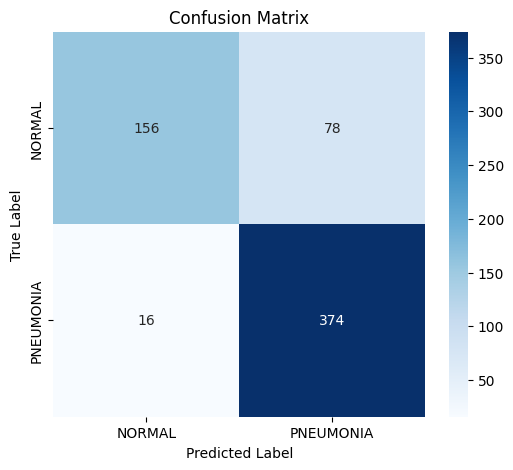

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict
pred_probs = model.predict(test_generator)
pred_classes = (pred_probs > 0.5).astype("int32").flatten()
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Classification report
print("Classification Report:\n")
print(classification_report(true_classes, pred_classes, target_names=class_labels))
print("\n")

# Confusion matrix
cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


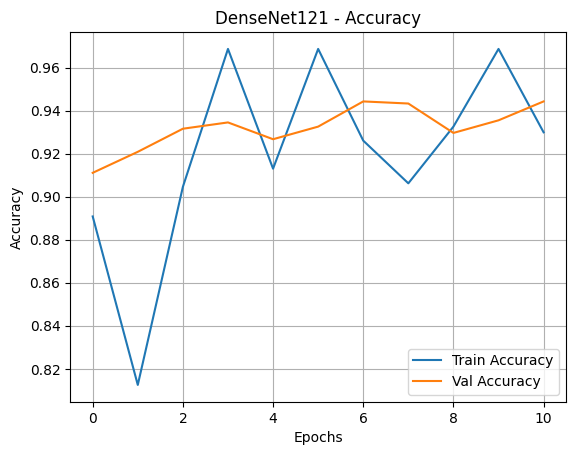

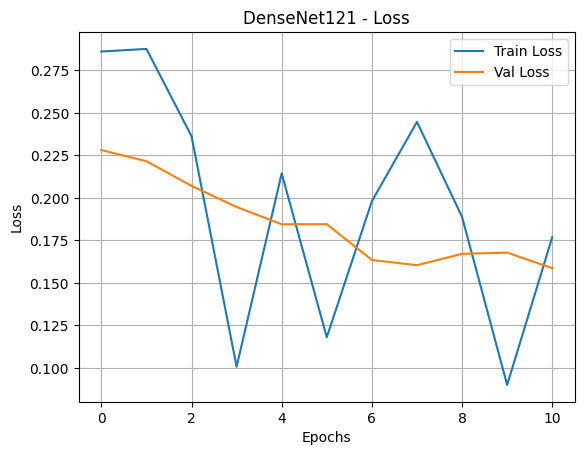

In [ ]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('DenseNet121 - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

print("\n")
# Loss plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('DenseNet121 - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


# phase 2 - fine tunning


In [ ]:
#load model
model = tf.keras.models.load_model('densenet121_initial.h5')


In [ ]:
# STEP 1: Unfreeze last 50 layers
# Count relevant DenseNet base layers (ignoring custom classifier)
count = 0
for layer in model.layers:
    if 'conv' in layer.name or 'dense' in layer.name or 'block' in layer.name:
        count += 1

# Freeze all except last 50 base layers
frozen = 0
for layer in model.layers:
    if 'conv' in layer.name or 'dense' in layer.name or 'block' in layer.name:
        if frozen < count - 50:
            layer.trainable = False
            frozen += 1
        else:
            layer.trainable = True
    else:
        layer.trainable = True  # Keep final classifier head trainable


In [ ]:
#step2 - recompile the model with lower learning rate
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),  # smaller LR for fine-tuning
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [ ]:
#callbacks
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint_cb = ModelCheckpoint(
    'densenet121_finetuned.h5',  # Save fine-tuned model
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

earlystop_cb = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)




In [ ]:
#train
history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[checkpoint_cb, earlystop_cb]  # add reduce_lr_cb here if used
)


Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 857ms/step - accuracy: 0.8102 - loss: 0.4488
Epoch 1: val_accuracy improved from -inf to 0.91659, saving model to densenet121_finetuned.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - accuracy: 0.8104 - loss: 0.4481 - val_accuracy: 0.9166 - val_loss: 0.2070
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 659ms/step - accuracy: 0.9050 - loss: 0.2410
Epoch 2: val_accuracy improved from 0.91659 to 0.93768, saving model to densenet121_finetuned.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 109s 827ms/step - accuracy: 0.9050 - loss: 0.2409 - val_accuracy: 0.9377 - val_loss: 0.1711
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 661ms/step - accuracy: 0.9160 - loss: 0.2059
Epoch 3: val_accuracy improved from 0.93768 to 0.94247, saving model to densenet121_finetuned.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 109s 834ms/step - accuracy: 0.9161 - loss: 0.2059 - val_accuracy: 0.9425 - val_loss: 0.1514
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 656ms/step - accuracy: 0.9326 - loss: 0.1873
Epoch 4: val_accuracy improved from 0.94247 to 0.94631, saving model to densenet121_finetuned.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 108s 826ms/step - accuracy: 0.9326 - loss: 0.1874 - val_accuracy: 0.9463 - val_loss: 0.1518
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 661ms/step - accuracy: 0.9255 - loss: 0.1824
Epoch 5: val_accuracy improved from 0.94631 to 0.95110, saving model to densenet121_finetuned.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 109s 834ms/step - accuracy: 0.9256 - loss: 0.1824 - val_accuracy: 0.9511 - val_loss: 0.1319
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 659ms/step - accuracy: 0.9330 - loss: 0.1676
Epoch 6: val_accuracy improved from 0.95110 to 0.95494, saving model to densenet121_finetuned.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 109s 832ms/step - accuracy: 0.9330 - loss: 0.1675 - val_accuracy: 0.9549 - val_loss: 0.1157
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 659ms/step - accuracy: 0.9408 - loss: 0.1526
Epoch 7: val_accuracy did not improve from 0.95494
131/131 ━━━━━━━━━━━━━━━━━━━━ 107s 817ms/step - accuracy: 0.9408 - loss: 0.1526 - val_accuracy: 0.9482 - val_loss: 0.1250
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 650ms/step - accuracy: 0.9486 - loss: 0.1508
Epoch 8: val_accuracy did not improve from 0.95494
131/131 ━━━━━━━━━━━━━━━━━━━━ 141s 811ms/step - accuracy: 0.9486 - loss: 0.1508 - val_accuracy: 0.9530 - val_loss: 0.1214
Epoch 9/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 655ms/step - accuracy: 0.9455 - loss: 0.1470
Epoch 9: val_accuracy improved from 0.95494 to 0.96165, saving model to densenet121_finetuned.h5


131/131 ━━━━━━━━━━━━━━━━━━━━ 108s 827ms/step - accuracy: 0.9455 - loss: 0.1470 - val_accuracy: 0.9616 - val_loss: 0.1049
Epoch 10/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 659ms/step - accuracy: 0.9596 - loss: 0.1203
Epoch 10: val_accuracy did not improve from 0.96165
131/131 ━━━━━━━━━━━━━━━━━━━━ 108s 825ms/step - accuracy: 0.9595 - loss: 0.1204 - val_accuracy: 0.9607 - val_loss: 0.1036
Restoring model weights from the end of the best epoch: 10.


In [ ]:
from tensorflow.keras.models import load_model

# Load the fine-tuned model
model = load_model('densenet121_finetuned.h5')


In [ ]:
# Evaluate the model
loss, accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Test Loss: {loss:.4f}")


20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 565ms/step - accuracy: 0.8246 - loss: 0.4858
Test Accuracy: 88.78%
Test Loss: 0.3225


20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 671ms/step
Classification Report:

              precision    recall  f1-score   support

      NORMAL       0.38      1.00      0.55       234
   PNEUMONIA       0.00      0.00      0.00       390

    accuracy                           0.38       624
   macro avg       0.19      0.50      0.27       624
weighted avg       0.14      0.38      0.20       624



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


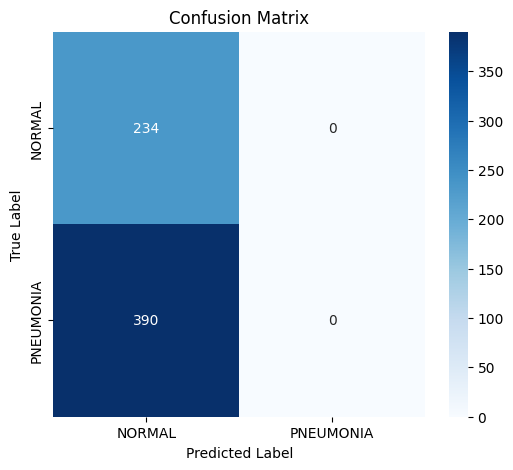

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Predict classes
pred_probs = model.predict(test_generator)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Classification report
print("Classification Report:\n")
print(classification_report(true_classes, pred_classes, target_names=class_labels))

# Confusion matrix
cm = confusion_matrix(true_classes, pred_classes)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

# Step 1: Load the model
model = tf.keras.models.load_model('densenet121_initial.h5')

# Step 2: Unfreeze top 30 layers of the full model
for layer in model.layers[:-30]:
    layer.trainable = False
for layer in model.layers[-30:]:
    layer.trainable = True

# Step 3: Compile with a low learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Step 4: Callbacks
checkpoint = ModelCheckpoint('densenet121_finetuned.h5', save_best_only=True, monitor='val_accuracy', mode='max')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-7, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1)

# Step 5: Train
history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[checkpoint, reduce_lr, early_stop]
)



Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 735ms/step - accuracy: 0.8797 - loss: 0.2934

131/131 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.8798 - loss: 0.2931 - val_accuracy: 0.9338 - val_loss: 0.1821 - learning_rate: 1.0000e-05
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 652ms/step - accuracy: 0.9127 - loss: 0.2202

131/131 ━━━━━━━━━━━━━━━━━━━━ 108s 824ms/step - accuracy: 0.9128 - loss: 0.2201 - val_accuracy: 0.9377 - val_loss: 0.1662 - learning_rate: 1.0000e-05
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 645ms/step - accuracy: 0.9231 - loss: 0.2050

131/131 ━━━━━━━━━━━━━━━━━━━━ 142s 820ms/step - accuracy: 0.9230 - loss: 0.2050 - val_accuracy: 0.9540 - val_loss: 0.1420 - learning_rate: 1.0000e-05
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 108s 822ms/step - accuracy: 0.9270 - loss: 0.1834 - val_accuracy: 0.9377 - val_loss: 0.1553 - learning_rate: 1.0000e-05
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - accuracy: 0.9329 - loss: 0.1844
Epoch 5: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
131/131 ━━━━━━━━━━━━━━━━━━━━ 107s 817ms/step - accuracy: 0.9329 - loss: 0.1844 - val_accuracy: 0.9358 - val_loss: 0.1538 - learning_rate: 1.0000e-05
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 106s 812ms/step - accuracy: 0.9244 - loss: 0.1944 - val_accuracy: 0.9434 - val_loss: 0.1507 - learning_rate: 2.0000e-06
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 107s 817ms/step - accuracy: 0.9405 - loss: 0.1563 - val_accuracy: 0.9511 - val_loss: 0.1324 - learning_rate: 2.0000e-06
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 106s 812ms/step -



20/20 ━━━━━━━━━━━━━━━━━━━━ 25s 684ms/step - accuracy: 0.7896 - loss: 0.4488
Test Loss: 0.2969
Test Accuracy: 0.8670


20/20 ━━━━━━━━━━━━━━━━━━━━ 22s 668ms/step




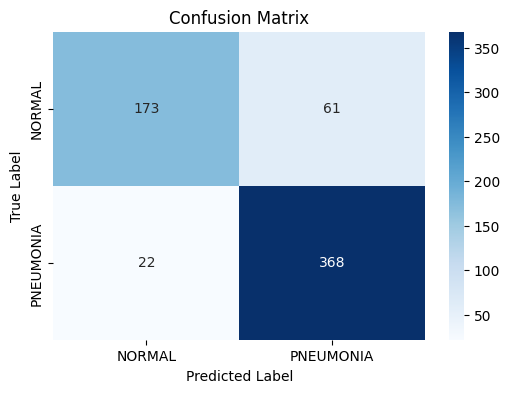



Classification Report:

              precision    recall  f1-score   support

      NORMAL       0.89      0.74      0.81       234
   PNEUMONIA       0.86      0.94      0.90       390

    accuracy                           0.87       624
   macro avg       0.87      0.84      0.85       624
weighted avg       0.87      0.87      0.86       624





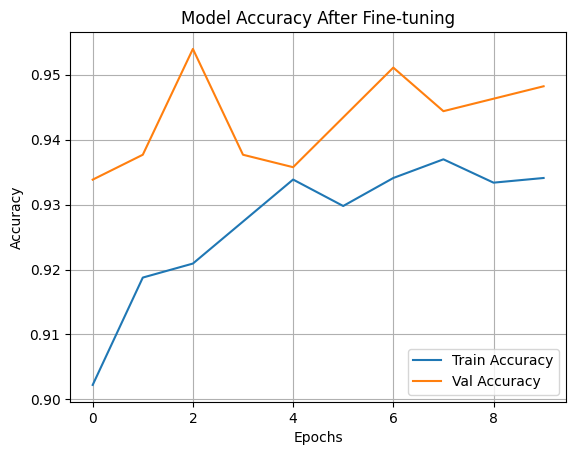

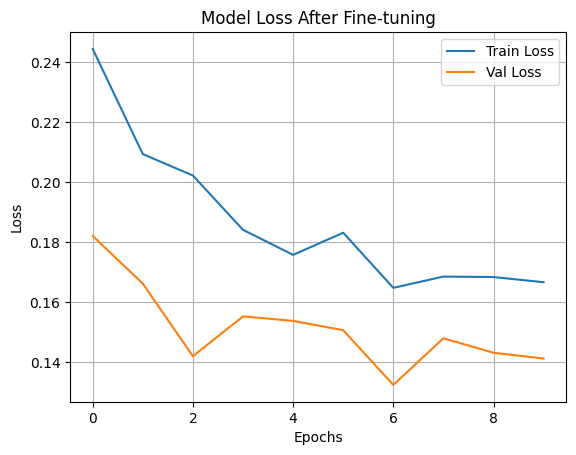

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import load_model

# Load the fine-tuned model
model = load_model('densenet121_finetuned.h5')
print("\n")
# Evaluate on test set
loss, accuracy = model.evaluate(test_generator)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print("\n")
# Predict on test set
y_pred_probs = model.predict(test_generator)
y_pred = (y_pred_probs > 0.5).astype("int32").reshape(-1)
y_true = test_generator.classes
print("\n")
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
labels = ['NORMAL', 'PNEUMONIA']

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
print("\n")
# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=labels))
print("\n")
# Plot Training & Validation Accuracy/Loss (optional: only if history exists)
try:
    plt.plot(history_finetune.history['accuracy'], label='Train Accuracy')
    plt.plot(history_finetune.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy After Fine-tuning')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()
    print("\n")
    plt.plot(history_finetune.history['loss'], label='Train Loss')
    plt.plot(history_finetune.history['val_loss'], label='Val Loss')
    plt.title('Model Loss After Fine-tuning')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
except:
    print("Training history not available for plotting.")


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


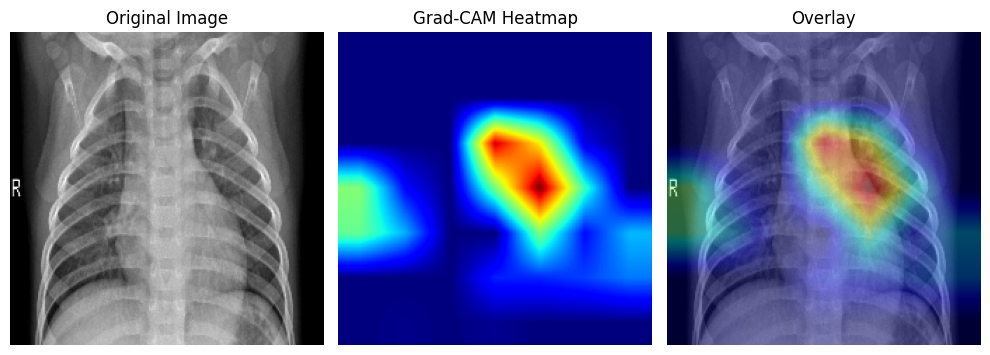

True Class: NORMAL, Predicted Class: NORMAL


In [ ]:
#one block grad Cam code
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
import random
import os

# Pick a random image from test set
class_names = ['NORMAL', 'PNEUMONIA']
test_class = random.choice(class_names)
test_class_dir = os.path.join(test_dir, test_class)
image_file = random.choice(os.listdir(test_class_dir))
img_path = os.path.join(test_class_dir, image_file)

# Load and preprocess the image
img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

# Get the last convolutional layer in DenseNet121
last_conv_layer_name = 'conv5_block16_2_conv'  # works for DenseNet121
grad_model = tf.keras.models.Model(
    [model.inputs],
    [model.get_layer(last_conv_layer_name).output, model.output]
)

# Compute gradients
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    pred_index = tf.argmax(predictions[0])
    class_channel = predictions[:, pred_index]

# Gradient of the output neuron with respect to conv layer
grads = tape.gradient(class_channel, conv_outputs)

# Mean intensity of the gradient over each feature map channel
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
conv_outputs = conv_outputs[0]

# Weight the conv outputs with pooled grads
heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)
heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
heatmap = heatmap.numpy()

# Superimpose heatmap on original image
img = cv2.imread(img_path)
img = cv2.resize(img, (224, 224))
heatmap = cv2.resize(heatmap, (224, 224))
heatmap = np.uint8(255 * heatmap)
heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
superimposed_img = cv2.addWeighted(img, 0.6, heatmap_color, 0.4, 0)

# Display
plt.figure(figsize=(10, 4))
plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Grad-CAM Heatmap")
plt.imshow(heatmap, cmap='jet')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Overlay")
plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"True Class: {test_class}, Predicted Class: {class_names[pred_index]}")


In [ ]:
model.save("densenet121_pneumonia_model.h5")
print("Model saved as densenet121_pneumonia_model.h5")

Model saved as densenet121_pneumonia_model.h5


In [ ]:
from google.colab import files

# Download the model file
files.download("densenet121_pneumonia_model.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>